# Motor Vehicle collisions

* link to dataset: https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/data_preview

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv(r"datasets\Motor_Vehicle_Collisions_-_Crashes_20260407.csv", delimiter=",")

C:\Users\lucas\AppData\Local\Temp\ipykernel_28680\2391632812.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"datasets\Motor_Vehicle_Collisions_-_Crashes_20260407.csv", delimiter=",")


In [4]:
# verify lfs is working by printing the first few rows of the dataset
data.head(1)

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN


## Preview

In [5]:
#The size of the dataset in MB
print(f"Size of the dataset: {data.memory_usage(deep=True).sum() / (1024 * 1024):.2f} MB")

Size of the dataset: 2233.05 MB


In [6]:
data.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253192 entries, 0 to 2253191
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       object 
 7   ON STREET NAME                 object 
 8   CROSS STREET NAME              object 
 9   OFF STREET NAME                object 
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CO

In [8]:
# print the range of dates in the dataset
print(data["CRASH DATE"].min())
print(data["CRASH DATE"].max())

01/01/2013
12/31/2025


In [9]:
# checking one example for each column
for col in data.columns:
    for i in range(len(data)):
        if pd.notna(data[col].iloc[i]):
            ddaa_example = data[col].iloc[i]
            break
    print(f"{col}: {ddaa_example}")

CRASH DATE: 09/11/2021
CRASH TIME: 2:39
BOROUGH: BROOKLYN
ZIP CODE: 11230.0
LATITUDE: 40.62179
LONGITUDE: -73.970024
LOCATION:     (40.62179, -73.970024)
ON STREET NAME: WHITESTONE EXPRESSWAY
CROSS STREET NAME: 20 AVENUE
OFF STREET NAME: 61        Ed Koch queensborough bridge
NUMBER OF PERSONS INJURED: 2.0
NUMBER OF PERSONS KILLED: 0.0
NUMBER OF PEDESTRIANS INJURED: 0
NUMBER OF PEDESTRIANS KILLED: 0
NUMBER OF CYCLIST INJURED: 0
NUMBER OF CYCLIST KILLED: 0
NUMBER OF MOTORIST INJURED: 2
NUMBER OF MOTORIST KILLED: 0
CONTRIBUTING FACTOR VEHICLE 1: Aggressive Driving/Road Rage
CONTRIBUTING FACTOR VEHICLE 2: Unspecified
CONTRIBUTING FACTOR VEHICLE 3: Unspecified
CONTRIBUTING FACTOR VEHICLE 4: Unspecified
CONTRIBUTING FACTOR VEHICLE 5: Unspecified
COLLISION_ID: 4455765
VEHICLE TYPE CODE 1: Sedan
VEHICLE TYPE CODE 2: Sedan
VEHICLE TYPE CODE 3: Sedan
VEHICLE TYPE CODE 4: Station Wagon/Sport Utility Vehicle
VEHICLE TYPE CODE 5: Station Wagon/Sport Utility Vehicle


In [10]:
# Combine the unique values from all three columns into one set
unique_factors = set(data["CONTRIBUTING FACTOR VEHICLE 1"]) | \
                 set(data["CONTRIBUTING FACTOR VEHICLE 2"]) | \
                 set(data["CONTRIBUTING FACTOR VEHICLE 3"])

print(f'Number of unique contributing factors: {len(unique_factors)}')
print(f'Unique contributing factors: {unique_factors}')

Number of unique contributing factors: 62
Unique contributing factors: {'Obstruction/Debris', 'Aggressive Driving/Road Rage', '80', 'Other Vehicular', 'Pavement Defective', 'Unsafe Lane Changing', 'Physical Disability', 'Failure to Yield Right-of-Way', 'Driver Inexperience', 'Eating or Drinking', 'Pedestrian/Bicyclist/Other Pedestrian Error/Confusion', 'Headlights Defective', 'Oversized Vehicle', 'Listening/Using Headphones', 'Texting', 'Outside Car Distraction', 'Tinted Windows', 'Lane Marking Improper/Inadequate', '1', 'View Obstructed/Limited', 'Reaction to Other Uninvolved Vehicle', 'Backing Unsafely', 'Accelerator Defective', 'Illness', 'Failure to Keep Right', 'Unspecified', 'Fell Asleep', 'Traffic Control Disregarded', 'Passenger Distraction', 'Other Lighting Defects', 'Unsafe Speed', 'Tow Hitch Defective', nan, 'Glare', 'Turning Improperly', 'Fatigued/Drowsy', 'Cell Phone (hand-held)', 'Passing or Lane Usage Improper', 'Reaction to Uninvolved Vehicle', 'Shoulders Defective/Impr

In [12]:
# removing all rows with missing values in Borough CODE column
print(f"Number of rows before removing missing Borough CODE: {len(data)}")
data_borough = data['BOROUGH'].copy()
data_borough = data_borough.dropna()
print(f"Number of rows after removing missing Borough CODE: {len(data_borough)}")

Number of rows before removing missing Borough CODE: 2253192
Number of rows after removing missing Borough CODE: 1565730


In [13]:
# removing all rows with missing values in ZIP CODE column
print(f"Number of rows before removing missing ZIP CODE: {len(data)}")
data_zip = data['ZIP CODE'].copy()
data_zip = data_zip.dropna()
print(f"Number of rows after removing missing ZIP CODE: {len(data_zip)}")

Number of rows before removing missing ZIP CODE: 2253192
Number of rows after removing missing ZIP CODE: 1565447


## Data preprocessing

## What month has the most accidents?

<Axes: title={'center': 'Number of Accidents per Month'}, xlabel='Month', ylabel='Number of Accidents'>

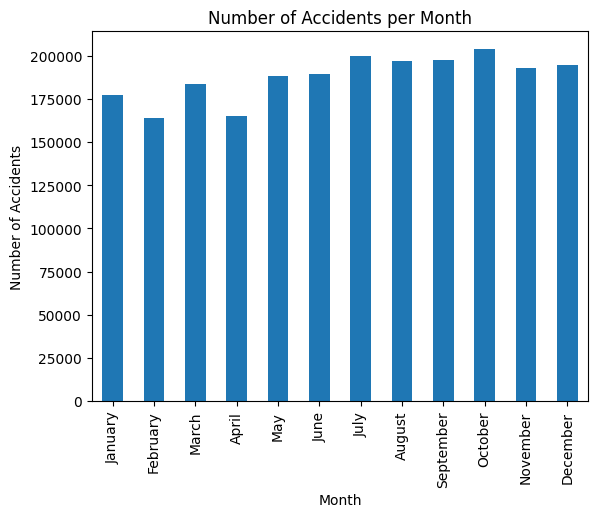

In [ ]:
# What month has the most accidents? We use the column "CRASH DATE" to extract the month and count the number of accidents for each month, create a bar plot comparing each month
data["CRASH DATE"] = pd.to_datetime(data["CRASH DATE"])
data["MONTH"] = data["CRASH DATE"].dt.month
month_counts = data["MONTH"].value_counts().sort_index()
# map each month to their name
month_counts.index = month_counts.index.map({1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"})
month_counts.plot(kind="bar", title="Number of Accidents per Month", xlabel="Month", ylabel="Number of Accidents")


## What time of day does crashes occur the most ? 

<Axes: title={'center': 'Number of Accidents per Hour'}, xlabel='Hour of Day', ylabel='Number of Accidents'>

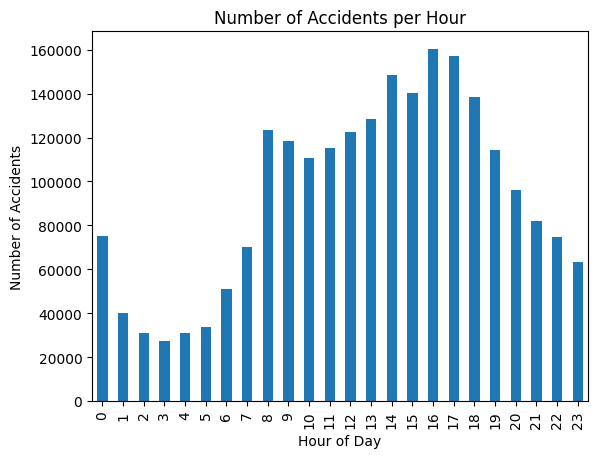

In [ ]:
# What time of day has the most accidents? We use the column "CRASH TIME" to extract the hour and count the number of accidents for each hour, create a bar plot comparing each hour
data["CRASH TIME"] = pd.to_datetime(data["CRASH TIME"], format="%H:%M")
data["HOUR"] = data["CRASH TIME"].dt.hour
hour_counts = data["HOUR"].value_counts().sort_index()
hour_counts.plot(kind="bar", title="Number of Accidents per Hour", xlabel="Hour of Day", ylabel="Number of Accidents")

## Do some zipcodes have more crashes ? 

In [ ]:
# Iterate over all values in zipcode columns and identify their types, only print unique types
unique_zipcode_types = data["ZIP CODE"].apply(type).unique()
print(unique_zipcode_types)

[<class 'float'> <class 'str'>]


In [ ]:
# What zipcode has the most accidents? We use the column "ZIP CODE" to count the number of accidents for each zipcode, create a bar plot comparing each zipcode
data["ZIP CODE"] = (
    data["ZIP CODE"]
    .astype(str)                           # convert everything to string first
    .str.strip()                           # remove whitespace
    .replace("", float("nan"))             # turn empty strings into NaN
    .dropna()                              # drop NaNs
    .astype(float)                         # normalize "10001.0" strings
    .astype(int)                           # drop the decimal
    .astype(str)                           # convert to string
    .str.zfill(5)                          # restore leading zeros
)
zipcode_counts = data["ZIP CODE"].dropna().value_counts().sort_index()
zipcode_counts.plot(kind="bar", title="Number of Accidents per Zipcode", xlabel="Zipcode", ylabel="Number of Accidents")


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

## Did vision zero mitigate crashes and/or fatalities? 

## When are crashes most deadly vs. most frequent?

## Which cross sections are most deadly ??

## Are some car owners more deadly than others ? Does it that say more about the car or the person ? 

## When does the most violent crashes occur (meaning more people die or not only injured) ?